# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [133]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [134]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths
from confounds import get_confounds

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")
dataset_path = Path("/data/datasets/hcph-dataset")
confounds_path = dataset_path / "phenotype" / "mood_env_quest.tsv"

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load confounds
confounds_df = get_confounds(dataset_path, confounds_path, confounds_of_interest=["slept_rest"])
# Keep only the magnitude part of functional scans and first echo
confounds_df = confounds_df[confounds_df["modality"] == "func"]
# Keep only the resting-state scans
confounds_df = confounds_df[confounds_df["task"].isin(["rest", "rsmovie"])]
# Drop columns that are not needed here
confounds_df = confounds_df.drop(columns=["filename", "modality", "task", "day_of_week", "time_of_day"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, confounds_df, on=["subject", "session"], how="inner"
    )

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1
# Merge the confounds in
df_rsmovie = pd.merge(df_rsmovie, confounds_df, on=["subject", "session"], how="inner")

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [135]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [136]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,acq_time,pe_dir,slept_rest,edge1,edge2,edge3,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,2024-08-20T21:19:11.542500,AP,Yes,5.713746e-07,6.540584e-07,7.533472e-02,⋯,-7.589415e-18,-2.301706e-17,-4.420834e-17,-9.459664e-17,3.980266e-02,-2.027458e-17,2.348138e-17,1.734723e-18,4.349188e-02,5.167582e-17
2,001,20102030,vidafit,1,2024-08-20T22:59:30.355000,RL,No,-3.001827e-06,-8.633434e-07,7.434885e-03,⋯,-1.006140e-16,-1.252525e-16,-3.995963e-17,-3.835365e-18,1.313193e-01,1.972221e-17,5.607677e-17,-1.649754e-17,3.675526e-18,-1.750475e-18
3,001,20103034,vida,1,2024-08-21T00:32:54.322500,PA,No,6.528042e-06,7.514955e-06,6.689939e-02,⋯,-3.903128e-16,9.413585e-17,-2.438371e-16,0.000000e+00,1.557758e-01,-1.322727e-16,-1.104921e-16,1.066855e-16,3.918115e-02,-1.469841e-16
4,001,20201060,prisma,2,2024-08-21T20:51:59.287500,RL,Yes,3.904534e-07,1.515389e-06,3.453112e-06,⋯,-2.295798e-17,3.557305e-17,1.848350e-17,-3.483355e-17,-6.859457e-17,1.501620e-17,-1.430277e-16,-4.933120e-17,2.647703e-03,-3.850324e-17
5,001,20202030,vidafit,2,2024-08-21T22:23:23.142500,AP,No,-1.454936e-06,-1.157484e-06,9.403329e-03,⋯,4.530888e-02,-7.994925e-17,-2.787828e-17,-8.960982e-17,9.983821e-02,3.426079e-17,-1.062243e-16,1.301043e-17,1.928596e-02,4.744856e-17
6,001,20203034,vida,2,2024-08-22T00:04:15.010000,RL,No,-4.514564e-06,2.766009e-02,1.460895e-05,⋯,4.049618e-02,-1.033938e-16,5.771188e-17,-1.590655e-16,-4.655646e-17,-1.710574e-16,-8.704852e-17,1.002208e-16,-7.124293e-17,-2.062372e-17


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [137]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_vals)

prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
5.167582e-17,-1.750475e-18,-1.469841e-16
-3.850324e-17,4.744856e-17,-2.062372e-17
1.681766e-17,5.344078e-18,1.076156e-16
-1.098919e-16,1.718209e-17,1.452872e-17
1.035807e-02,-5.010170e-17,6.270949e-17
-7.349301e-17,-1.836159e-16,-8.626545e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0172390994
2,edge2,-0.0469087433
3,edge3,-0.0234311629
4,edge4,-0.1738795027
5,edge5,-0.0539968901
6,edge6,-0.0003582582


Mean ICC across edges: -0.02419042 
Median ICC across edges: -0.01757463 


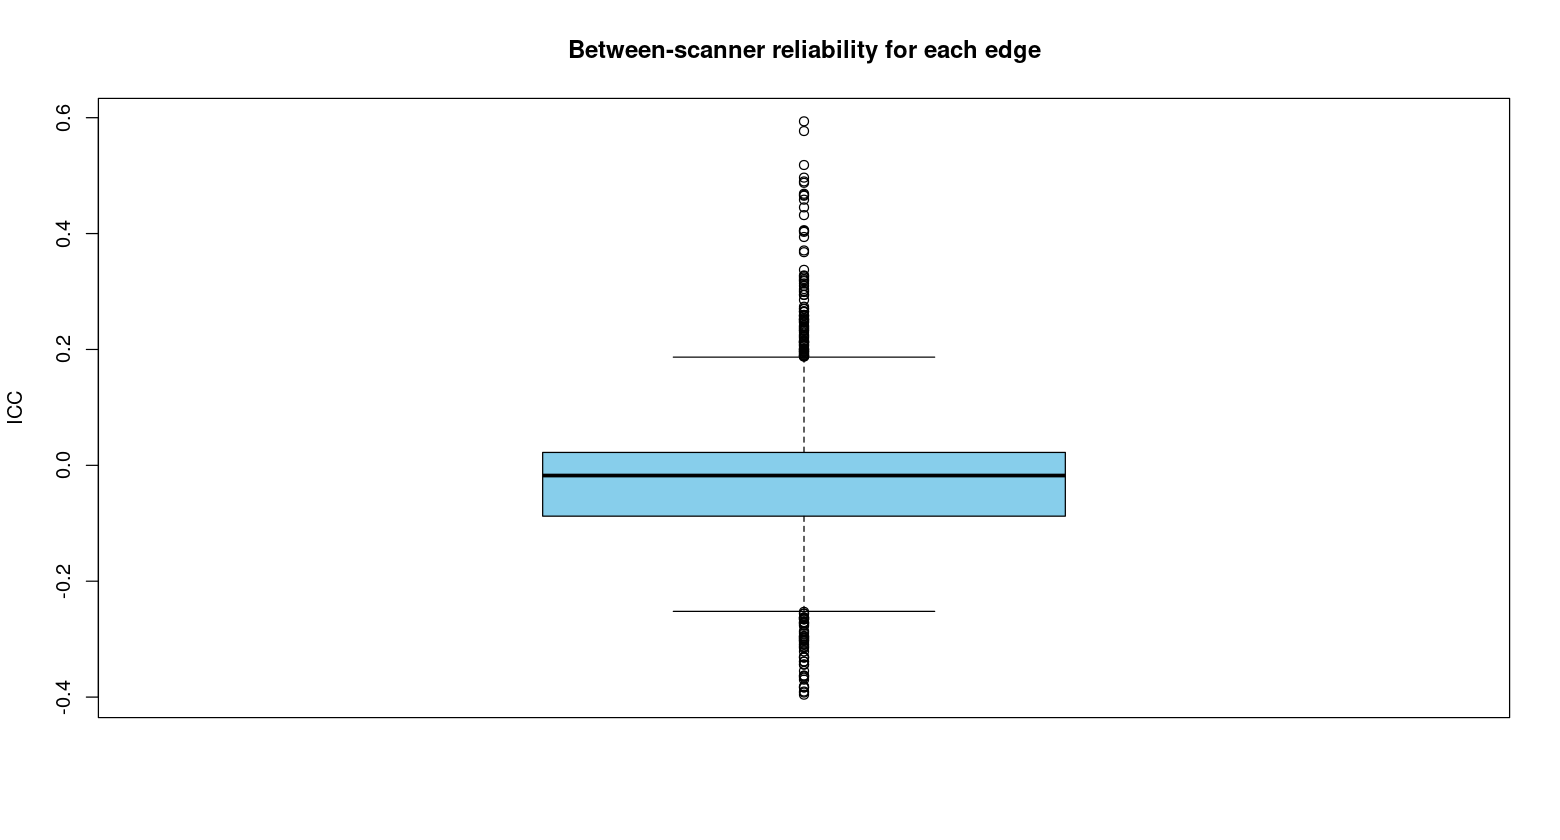

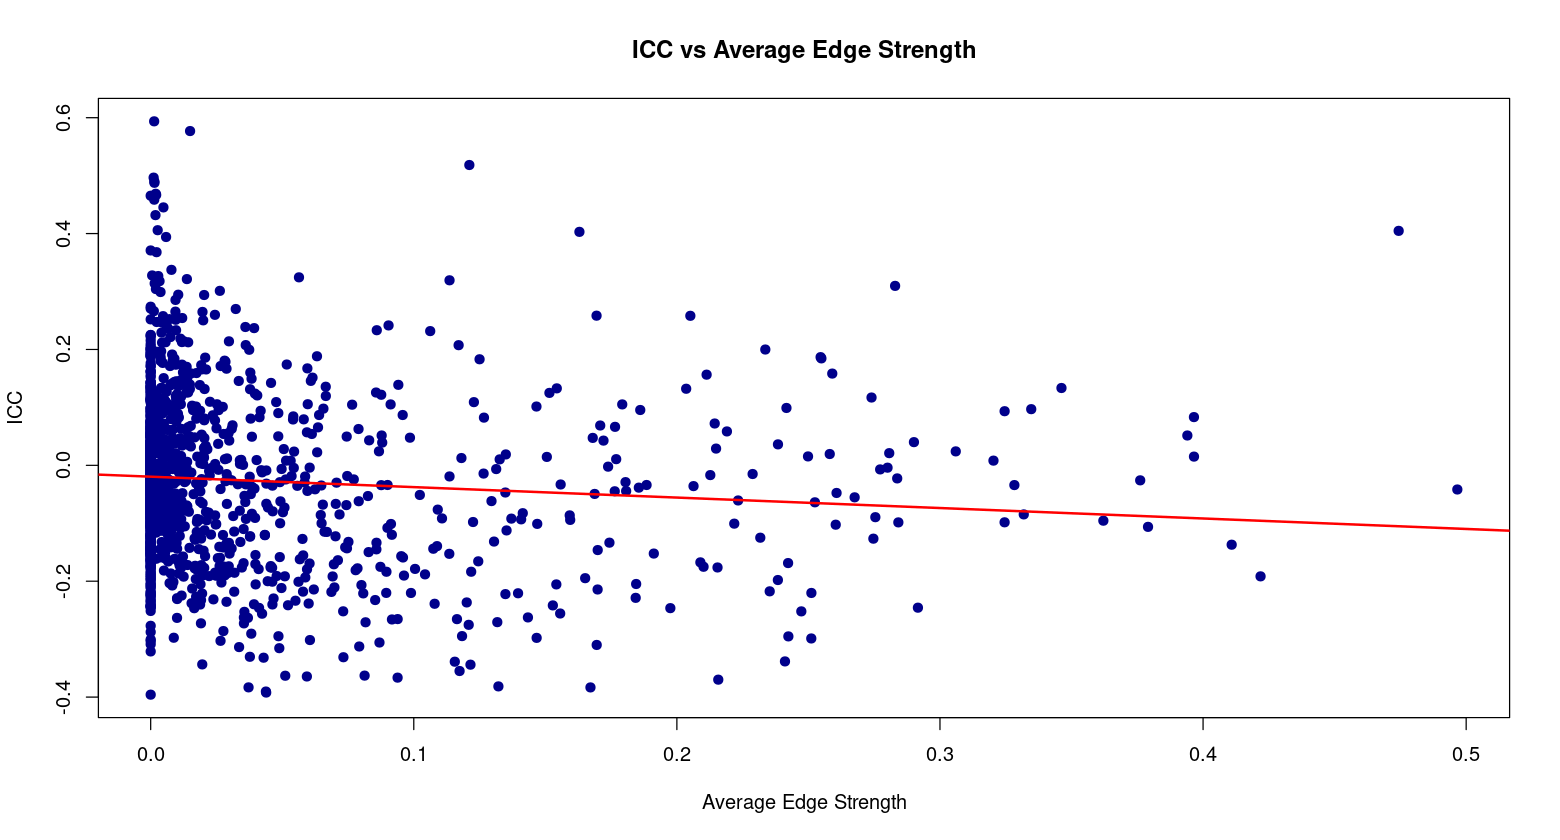

In [138]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_fc[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [ ]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), stringsAsFactors = FALSE)

scanners <- unique(df_fc$scanner)
# Iterate over the three possible scanner pairs
for (i in 1:2) {
  for (j in (i + 1):3) {

    # Iterate over all possible pairs of repetition
    for (rep1 in 1:12) {
      for (rep2 in 1:12) {
        sc1 <- scanners[i]
        sc2 <- scanners[j]

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_fc, scanner == sc1 & repetition == rep1), subset(df_fc, scanner == sc2 & repetition == rep2))

        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
          if (any(is.na(df_rep$slept))) {
              # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
              slept <- NA
          } else {
              df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
              slept <- sum(df_rep$slept)
          }

        # Keep only the edge column and trasnpose the dataframe
        col_names <- df_rep$scanner
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- col_names

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = paste0(scanners[i], "-", scanners[j]),
            repetition = paste0(rep1, "-", rep2),
            ICC = icc_val,
            summary_statistic = NA,
            days_diff = NA,
            slept = slept
            )
        )  
      }
    }
  }
}

head(df_rep)
head(icc_between)

,subject,session,scanner,repetition,acq_time,pe_dir,slept_rest,edge1,edge2,edge3,⋯,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891,slept
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
34,001,21201030,vidafit,12,2024-09-04T22:03:14.402500,RL,Yes,-1.052766e-06,-1.828220e-06,1.497237e-01,⋯,-1.829030e-18,-6.324279e-18,5.503131e-17,0.04869998,-3.171171e-17,2.214591e-17,2.255239e-17,5.606462e-17,-1.793980e-17,1
35,001,21202034,vida,12,2024-09-04T23:53:45.627500,LR,No,-1.245544e-05,8.131475e-06,-2.167989e-05,⋯,-6.635317e-17,-5.546768e-17,-1.068744e-16,0.07288537,3.981117e-17,5.584283e-17,9.981604e-18,-1.399680e-17,2.566444e-02,0


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<dbl>
between-scanner,rest,prisma-vidafit,1-1,0.7248010,NA,NA,1
between-scanner,rest,prisma-vidafit,1-2,0.6914540,NA,NA,1
between-scanner,rest,prisma-vidafit,1-3,0.6857878,NA,NA,1
between-scanner,rest,prisma-vidafit,1-4,0.8622219,NA,NA,2
between-scanner,rest,prisma-vidafit,1-5,0.8590276,NA,NA,2
between-scanner,rest,prisma-vidafit,1-6,0.6843263,NA,NA,1
between-scanner,rest,prisma-vidafit,1-7,0.7075090,NA,NA,NA
between-scanner,rest,prisma-vidafit,1-8,0.8606580,NA,NA,2
between-scanner,rest,prisma-vidafit,1-9,0.6983707,NA,NA,1


In [225]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.7962891 
Quantiles (25%, median, 75%): 0.7290755 0.8052386 0.858852 


## ICC to quantify intra-scanner variability when using standard resting-state

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

### Using all 12 sessions

In [142]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

ICC of for prisma scanner: 0.7800
ICC of for vidafit scanner: 0.7962
ICC of for vida scanner: 0.8155


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,6.528042e-06,-4.514564e-06,-8.506657e-06,-3.215814e-06,-5.611867e-06,-1.163362e-06,-1.055886e-06,9.467434e-07,3.087218e-06,1.113368e-06,-4.712413e-06,-1.245544e-05
edge2,7.514955e-06,2.766009e-02,-4.268188e-06,-1.695434e-06,-9.683560e-07,3.029625e-06,-9.775773e-06,-1.016135e-06,7.646137e-07,-4.235880e-06,-6.342809e-06,8.131475e-06
edge3,6.689939e-02,1.460895e-05,9.157005e-02,9.144441e-02,3.725246e-03,1.416232e-01,9.480423e-08,4.164482e-02,1.045742e-02,-4.391880e-06,8.693893e-02,-2.167989e-05
edge4,7.235371e-06,4.672855e-04,1.805981e-02,6.709116e-02,6.825498e-02,5.305358e-02,4.791103e-02,1.185077e-02,-2.287152e-05,2.343900e-05,9.511922e-03,1.151996e-05
edge5,-7.886987e-07,-4.646385e-06,-4.847092e-06,-7.981107e-07,1.155399e-07,-1.123034e-06,7.750204e-07,-9.281694e-09,1.307680e-06,-1.880596e-06,6.730842e-08,-7.215465e-06
edge6,7.797121e-06,-2.661734e-07,-1.059137e-06,-1.370371e-06,-2.018452e-06,1.328749e-07,-2.814641e-07,-2.565683e-07,-3.477949e-07,-1.781178e-06,-2.678140e-09,5.341054e-06


### Bootstrap all possible pairs of repetitions

In [143]:
icc_intra_rest <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), stringsAsFactors = FALSE)

for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    # Iterate over all possible pairs of repetition
    for (rep1 in 1:11) {
      # Ensure rep2 is always greater than rep1 to avoid duplicates
      for (rep2 in (rep1+1):12) {

            # Extract that permutation of repetitions
            df_rep <- rbind(subset(df_scanner, repetition == rep1), subset(df_scanner, repetition == rep2))
            # Compute how many days apart the two repetitions are
            days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
            # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }

            #Keep only the edge column and transpose the dataframe
            df_rep <- t(df_rep[, edge_keys])

            # Compute ICC(2,1)
            icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
            icc_intra_rest <- rbind(icc_intra_rest, data.frame(variability_type = "within-scanner", task="rest", scanner=scanner, repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept))
        }
    }
}
head(df_rep)
head(icc_intra_rest)

,31,35
edge1,-4.712413e-06,-1.245544e-05
edge2,-6.342809e-06,8.131475e-06
edge3,8.693893e-02,-2.167989e-05
edge4,9.511922e-03,1.151996e-05
edge5,6.730842e-08,-7.215465e-06
edge6,-2.678140e-09,5.341054e-06


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
within-scanner,rest,prisma,1-2,0.8411719,NA,1,2
within-scanner,rest,prisma,1-3,0.8031777,NA,2,2
within-scanner,rest,prisma,1-4,0.6667641,NA,3,1
within-scanner,rest,prisma,1-5,0.6836485,NA,4,1
within-scanner,rest,prisma,1-6,0.8539780,NA,5,2
within-scanner,rest,prisma,1-7,0.7105431,NA,7,1
within-scanner,rest,prisma,1-8,0.6772230,NA,9,1
within-scanner,rest,prisma,1-9,0.6778277,NA,9,1
within-scanner,rest,prisma,1-10,0.8361519,NA,11,2


In [144]:
for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    cat("Scanner:", scanner, "\n")
    cat("Mean ICC across edges:", mean_icc, "\n")
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    cat("Quantiles (25%, median, 75%):", quantiles, "\n")

    icc_intra_rest <- rbind(
        icc_intra_rest,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = slept)
    )
}

Scanner: prisma 
Mean ICC across edges: 0.7798401 
Quantiles (25%, median, 75%): 0.7138741 0.7544129 0.8457678 
Scanner: vidafit 
Mean ICC across edges: 0.7952864 
Quantiles (25%, median, 75%): 0.7186016 0.8030623 0.8593237 
Scanner: vida 
Mean ICC across edges: 0.8160605 
Quantiles (25%, median, 75%): 0.7821268 0.8340833 0.8628899 


## ICC to quantify intra-scanner variability when using naturalistic movie

### Using all 36 sessions

In [145]:
df_intra_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_intra_rsmovie)
icc_val_intra_rsmovie <- icc(df_intra_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val_intra_rsmovie))

edge1,1.102220e-06,6.415947e-06,-4.595372e-06,3.259803e-06,1.441370e-05,7.021473e-06,-1.020239e-06,5.842345e-05,-7.386642e-07,-1.819866e-06,⋯,1.427782e-07,1.067174e-06,-4.284423e-06,-1.063658e-05,-6.137563e-06,-4.678330e-06,-4.588838e-07,-5.199323e-06,-1.930210e-06,1.125792e-06
edge2,-7.794015e-07,-6.468752e-07,-2.194737e-06,-6.716801e-07,6.054336e-06,2.366883e-06,1.464118e-07,1.635985e-04,3.472887e-06,-1.046269e-07,⋯,-2.036710e-07,9.921960e-08,-3.770929e-06,3.638309e-02,-7.807891e-06,1.433800e-02,-4.062786e-07,1.576103e-02,5.235316e-02,6.780837e-06
edge3,1.139434e-05,5.280384e-06,-8.793063e-06,5.543463e-03,1.137742e-05,5.896386e-02,-1.159955e-06,4.520909e-05,-1.051122e-06,-7.542363e-06,⋯,-2.609990e-06,-2.594676e-06,-5.589937e-06,2.233237e-02,1.421963e-01,-1.567289e-05,-2.738721e-06,9.256322e-06,-1.077018e-05,5.888299e-07
edge4,-2.108473e-05,3.844471e-02,6.452152e-02,3.652434e-02,5.151805e-02,2.030996e-05,4.823714e-02,8.268471e-02,4.989634e-02,5.762318e-02,⋯,4.310278e-02,4.568402e-02,2.367034e-05,-3.039112e-05,-2.870628e-05,7.280732e-06,-5.724659e-06,-2.320633e-06,-1.551173e-06,9.287778e-06
edge5,-5.255465e-07,1.069534e-06,-1.941939e-06,1.990934e-07,6.011015e-06,-1.473689e-07,-4.917529e-07,1.050275e-04,2.452045e-07,-9.815775e-07,⋯,-1.558604e-07,3.366410e-07,-3.251314e-06,3.433093e-06,1.607545e-07,-1.188681e-06,1.352869e-07,1.584268e-08,1.891379e-07,-1.540721e-06
edge6,-6.066261e-06,4.212206e-07,-4.056693e-06,-7.268224e-07,5.638678e-06,1.130457e-06,-5.580014e-08,2.000679e-04,-1.388992e-07,-1.986019e-08,⋯,-2.985605e-07,8.313284e-08,-2.428235e-06,2.739582e-06,-3.661786e-06,6.245403e-06,-4.533894e-08,-4.280846e-07,5.141747e-07,5.194488e-06


ICC for rsmovie: 0.8726


### Bootstrap to permute through all possible pairs of repetitions

In [146]:
icc_intra_rsmovie <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(),slept = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible pairs of repetition
for (rep1 in 1:35) {
  # Ensure rep2 is always greater than rep1 to avoid duplicates
  for (rep2 in (rep1+1):36) {

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_rsmovie, repetition == rep1), subset(df_rsmovie, repetition == rep2))
        # Compute how many days apart the two repetitions are
        days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
        
        #Keep only the edge column and transpose the dataframe
        df_rep <- t(df_rep[, edge_keys])

        # Compute ICC(2,1)
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_intra_rsmovie <- rbind(icc_intra_rsmovie, data.frame(variability_type = "within-scanner", task="rsmovie", scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept))
    }
}
head(df_rep)
head(icc_intra_rsmovie)

,35,36
edge1,-1.930210e-06,1.125792e-06
edge2,5.235316e-02,6.780837e-06
edge3,-1.077018e-05,5.888299e-07
edge4,-1.551173e-06,9.287778e-06
edge5,1.891379e-07,-1.540721e-06
edge6,5.141747e-07,5.194488e-06


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
within-scanner,rsmovie,prisma,1-2,0.8672726,NA,1,NA
within-scanner,rsmovie,prisma,1-3,0.8910870,NA,1,NA
within-scanner,rsmovie,prisma,1-4,0.9170888,NA,2,NA
within-scanner,rsmovie,prisma,1-5,0.8804258,NA,2,NA
within-scanner,rsmovie,prisma,1-6,0.8710908,NA,3,NA
within-scanner,rsmovie,prisma,1-7,0.8849407,NA,3,NA
within-scanner,rsmovie,prisma,1-8,0.8954146,NA,4,NA
within-scanner,rsmovie,prisma,1-9,0.8757690,NA,4,NA
within-scanner,rsmovie,prisma,1-10,0.8769438,NA,5,NA


In [147]:
mean_icc <- mean(icc_intra_rsmovie$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_intra_rsmovie$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_intra_rsmovie <- rbind(
    icc_intra_rsmovie,
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.8723939 
Quantiles (25%, median, 75%): 0.8581244 0.8760093 0.8911141 


## ICC to quantify variability across paradigms

In [148]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
5.167582e-17,8.938102e-17
-3.850324e-17,6.357596e-03
1.681766e-17,8.454763e-17
-1.098919e-16,1.789807e-17
1.035807e-02,5.087166e-03
-7.349301e-17,4.316731e-17
-3.314509e-17,-1.642213e-16
3.888169e-02,1.588796e-02
7.479356e-17,6.514770e-18


,edge,ICC
,<chr>,<dbl>
1,edge1,0.06795108
2,edge2,0.02523054
3,edge3,-0.01427165
4,edge4,-0.37634054
5,edge5,0.02838285
6,edge6,-0.01217159


Mean ICC across edges: 0.002907957 
Median ICC across edges: -1.044961e-05 


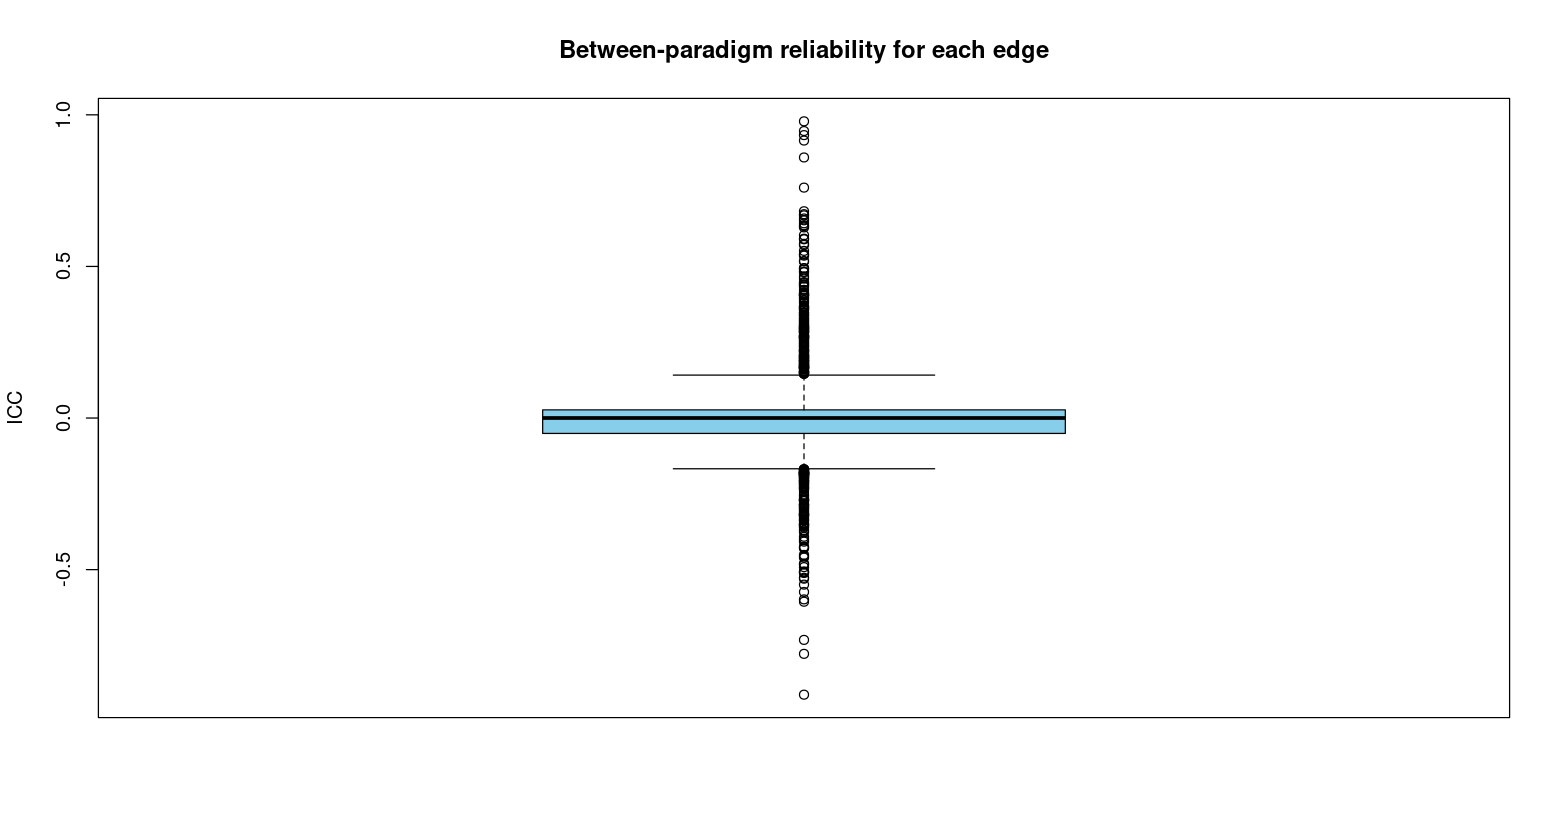

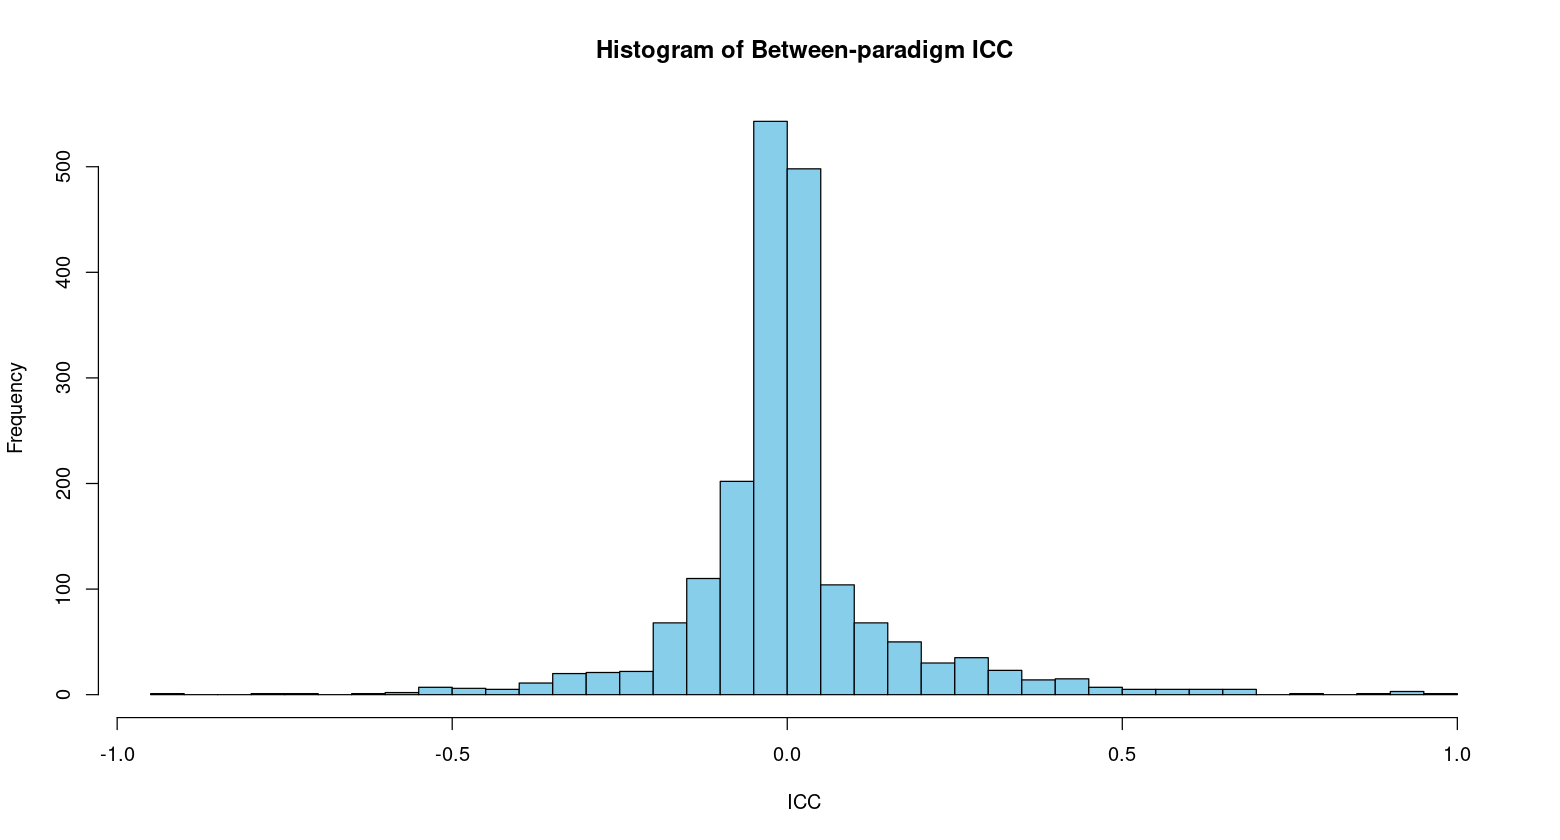

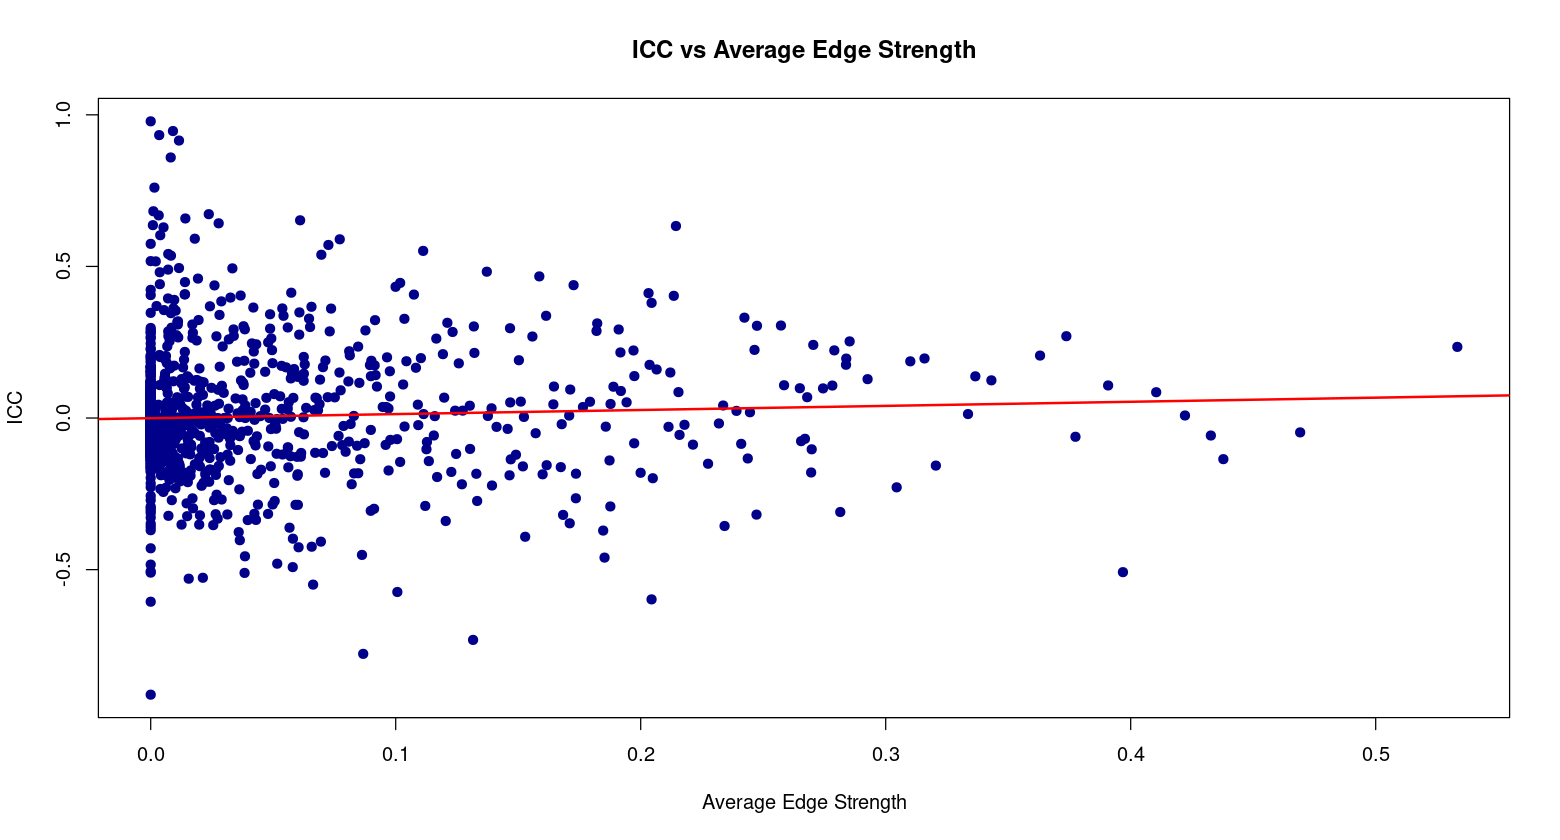

In [149]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")
hist(icc_vals$ICC, breaks = 30, main = "Histogram of Between-paradigm ICC", xlab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_paradigm[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [150]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept= numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
        if (any(is.na(df_rep$slept))) {
            # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
            slept <- NA
        } else {
            df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
            slept <- sum(df_rep$slept)
        }
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept = slept))
    }
}
head(df_rep)
head(icc_paradigm)

,rest,rsmovie
edge1,-1.738165e-06,1.125792e-06
edge2,-1.091652e-06,6.780837e-06
edge3,1.356319e-05,5.888299e-07
edge4,6.414071e-02,9.287778e-06
edge5,4.221924e-07,-1.540721e-06
edge6,3.592163e-07,5.194488e-06


variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
between-paradigm,NA,prisma,1-1,0.6526815,NA,0,NA
between-paradigm,NA,prisma,1-2,0.7528309,NA,0,NA
between-paradigm,NA,prisma,1-3,0.6810927,NA,0,1
between-paradigm,NA,prisma,1-4,0.6820359,NA,0,1
between-paradigm,NA,prisma,1-5,0.6857914,NA,0,1
between-paradigm,NA,prisma,1-6,0.7252604,NA,0,1
between-paradigm,NA,prisma,1-7,0.6759592,NA,0,1
between-paradigm,NA,prisma,1-8,0.7103866,NA,0,1
between-paradigm,NA,prisma,1-9,0.6991142,NA,0,1


In [151]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.7718473 
Quantiles (25%, median, 75%): 0.7202751 0.7796572 0.8268158 


## Save the ICC estimates in a table

We use pybids to determine the filename to save the table.

In [228]:
icc_results <- rbind(icc_between, icc_paradigm, icc_intra_rsmovie, icc_intra_rest)

py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

## Visualize the ICC results

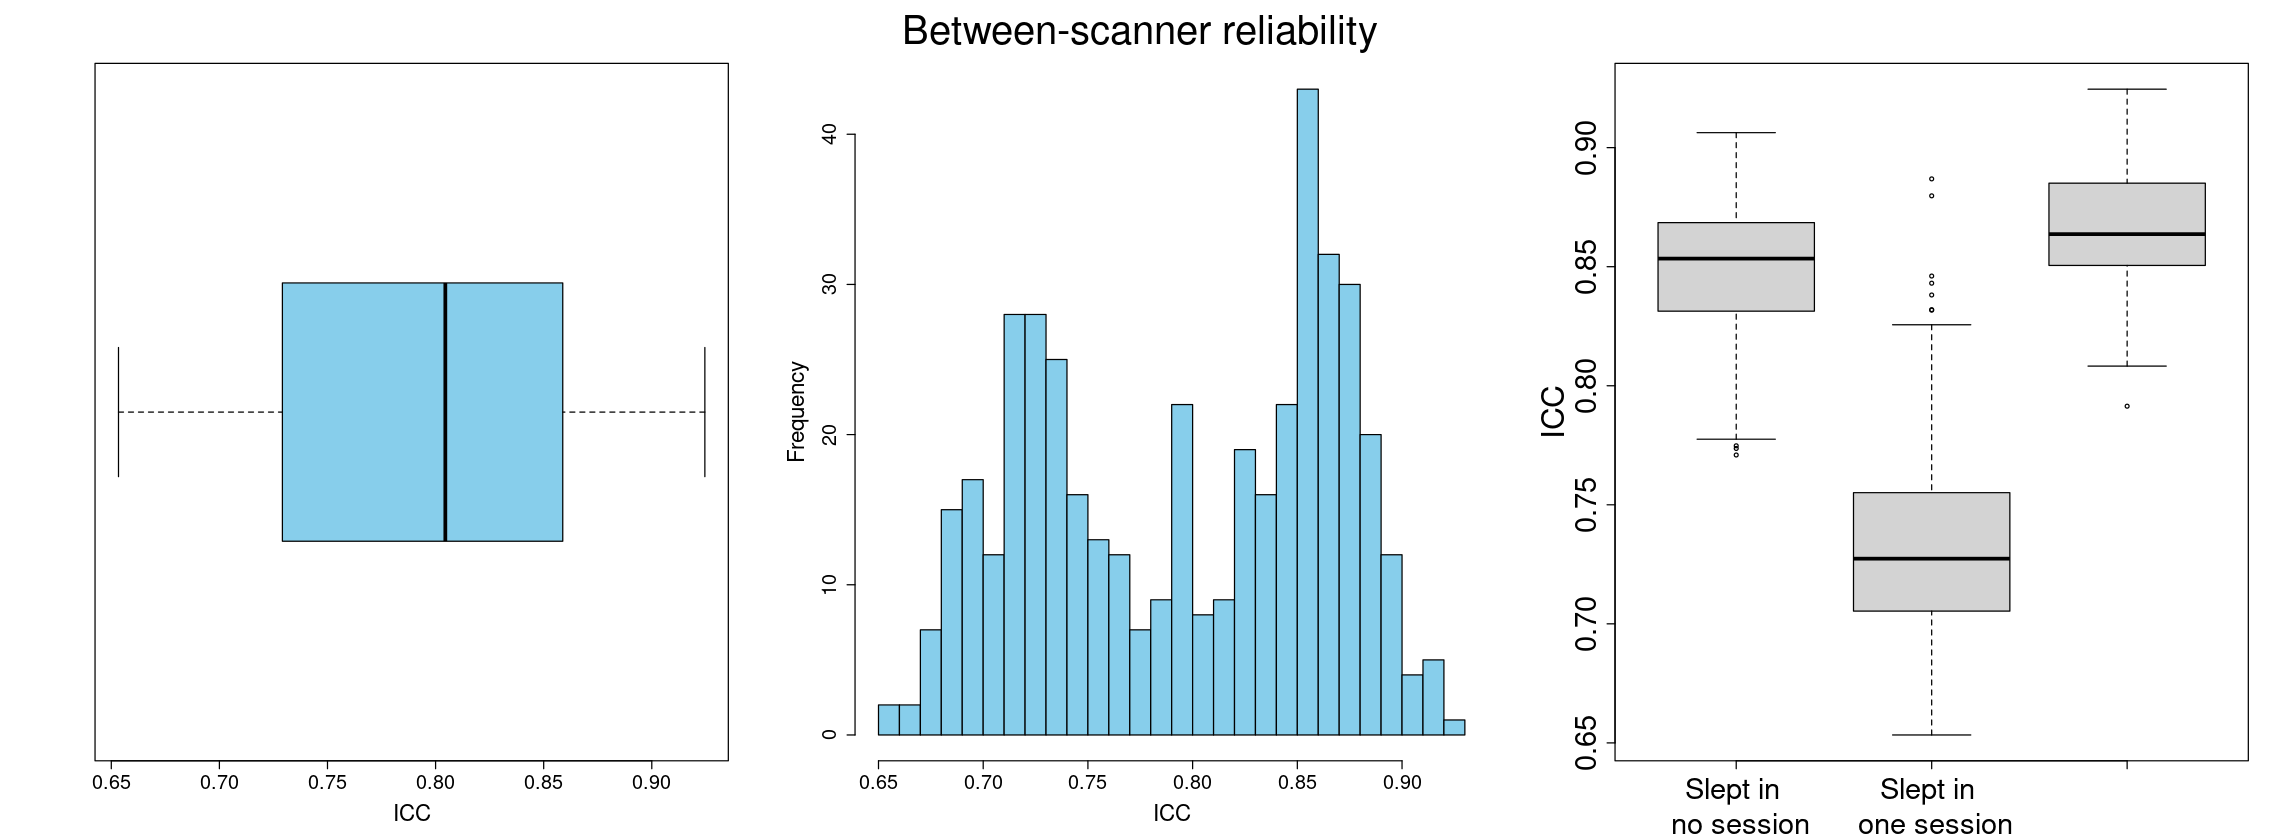

In [227]:
# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 19, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2, cex.lab = 2, cex.main = 2, cex.sub = 2, mar = c(5, 6, 4, 2))  # Increase left margin

boxplot(
    icc_between$ICC,
    horizontal = TRUE,
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
hist(
    icc_between$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
# Sleep influence on ICC
icc_between$slept_factor <- factor(
    icc_between$slept,
    levels = c(0, 1, 2),
    labels = c("Slept in \n no session", "Slept in \n one session", "Slept in \n both sessions")
)

boxplot(
    ICC ~ slept_factor, data = icc_between,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:3,
    labels = levels(icc_between$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Between-scanner reliability", outer = TRUE, line = -3, cex = 2)
par(mfrow = c(1, 1))  # Reset plotting area

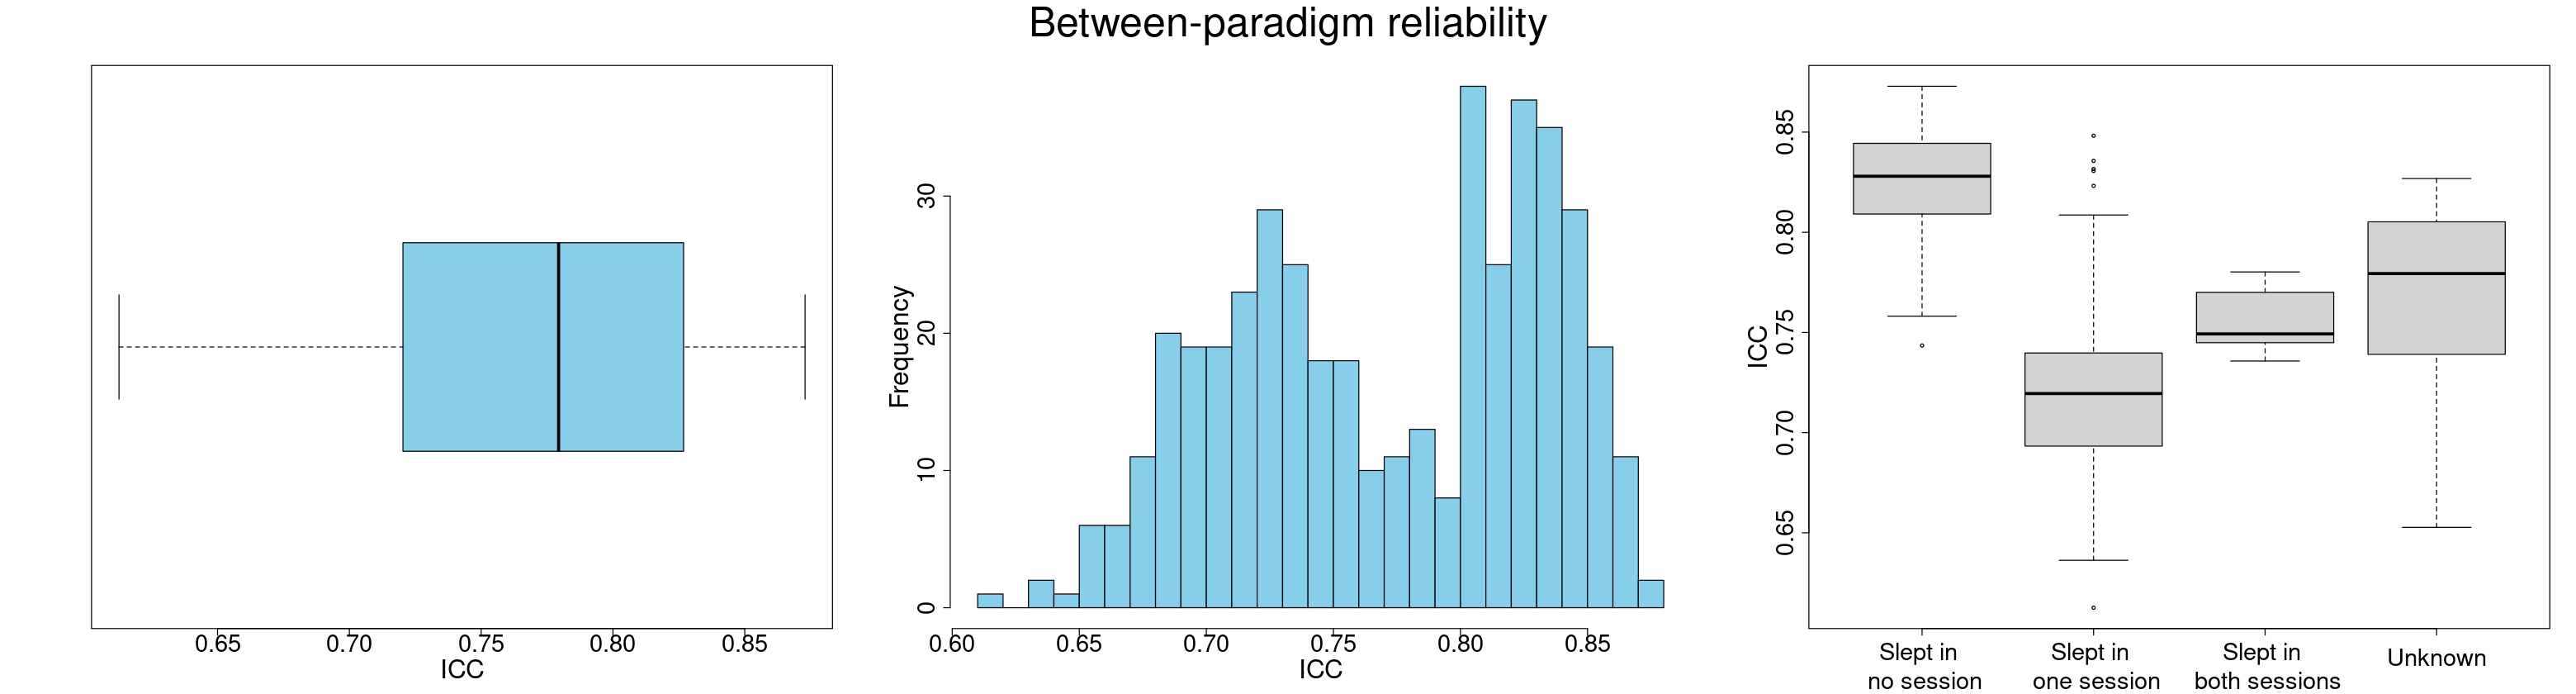

In [214]:
# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 26, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes

boxplot(
    icc_paradigm$ICC,
    horizontal = TRUE,
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
hist(
    icc_paradigm$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
# Sleep influence on ICC
icc_paradigm$slept_factor <- factor(
    ifelse(is.na(icc_paradigm$slept), -1, icc_paradigm$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in \n no session", "Slept in \n one session", "Slept in \n both sessions", "Unknown")
)

boxplot(
    ICC ~ slept_factor, data = icc_paradigm,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:4,
    labels = levels(icc_paradigm$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Between-paradigm reliability", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

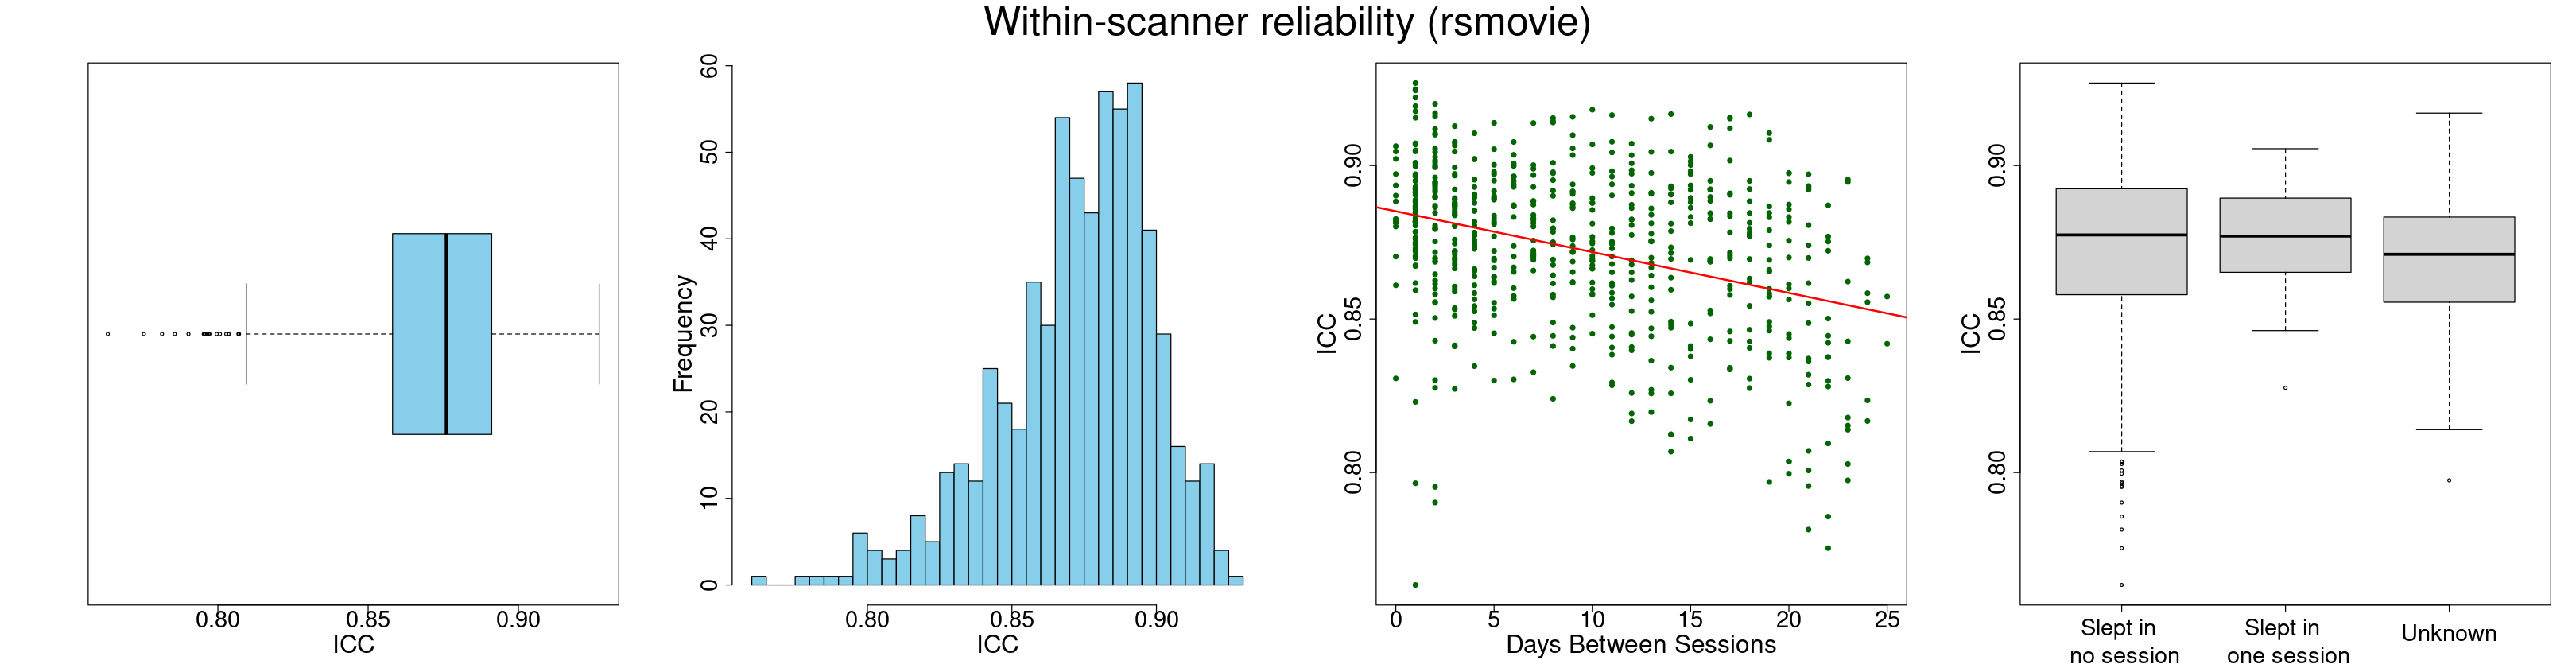

In [197]:
# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 27, repr.plot.height = 7)
par(mfrow = c(1, 4), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes

boxplot(
    icc_intra_rsmovie$ICC,
    horizontal = TRUE,
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
hist(
    icc_intra_rsmovie$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
plot(
    icc_intra_rsmovie$days_diff, icc_intra_rsmovie$ICC,
    xlab = "Days Between Sessions",
    ylab = "ICC",
    main = "",
    pch = 19, col = "darkgreen",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ days_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)

# Sleep influence on ICC
icc_intra_rsmovie$slept_factor <- factor(
    ifelse(is.na(icc_intra_rsmovie$slept), -1, icc_intra_rsmovie$slept),
    levels = c(0, 1, -1),
    labels = c("Slept in \n no session", "Slept in \n one session", "Unknown")
)

boxplot(
    ICC ~ slept_factor, data = icc_intra_rsmovie,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:3,
    labels = levels(icc_intra_rsmovie$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Within-scanner reliability (rsmovie)", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

In [191]:
icc_intra_rsmovie

,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,slept_factor
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<fct>
1,within-scanner,rsmovie,prisma,1-2,0.8672726,NA,1,NA,NA
2,within-scanner,rsmovie,prisma,1-3,0.8910870,NA,1,NA,NA
3,within-scanner,rsmovie,prisma,1-4,0.9170888,NA,2,NA,NA
4,within-scanner,rsmovie,prisma,1-5,0.8804258,NA,2,NA,NA
5,within-scanner,rsmovie,prisma,1-6,0.8710908,NA,3,NA,NA
6,within-scanner,rsmovie,prisma,1-7,0.8849407,NA,3,NA,NA
7,within-scanner,rsmovie,prisma,1-8,0.8954146,NA,4,NA,NA
8,within-scanner,rsmovie,prisma,1-9,0.8757690,NA,4,NA,NA
9,within-scanner,rsmovie,prisma,1-10,0.8769438,NA,5,NA,NA


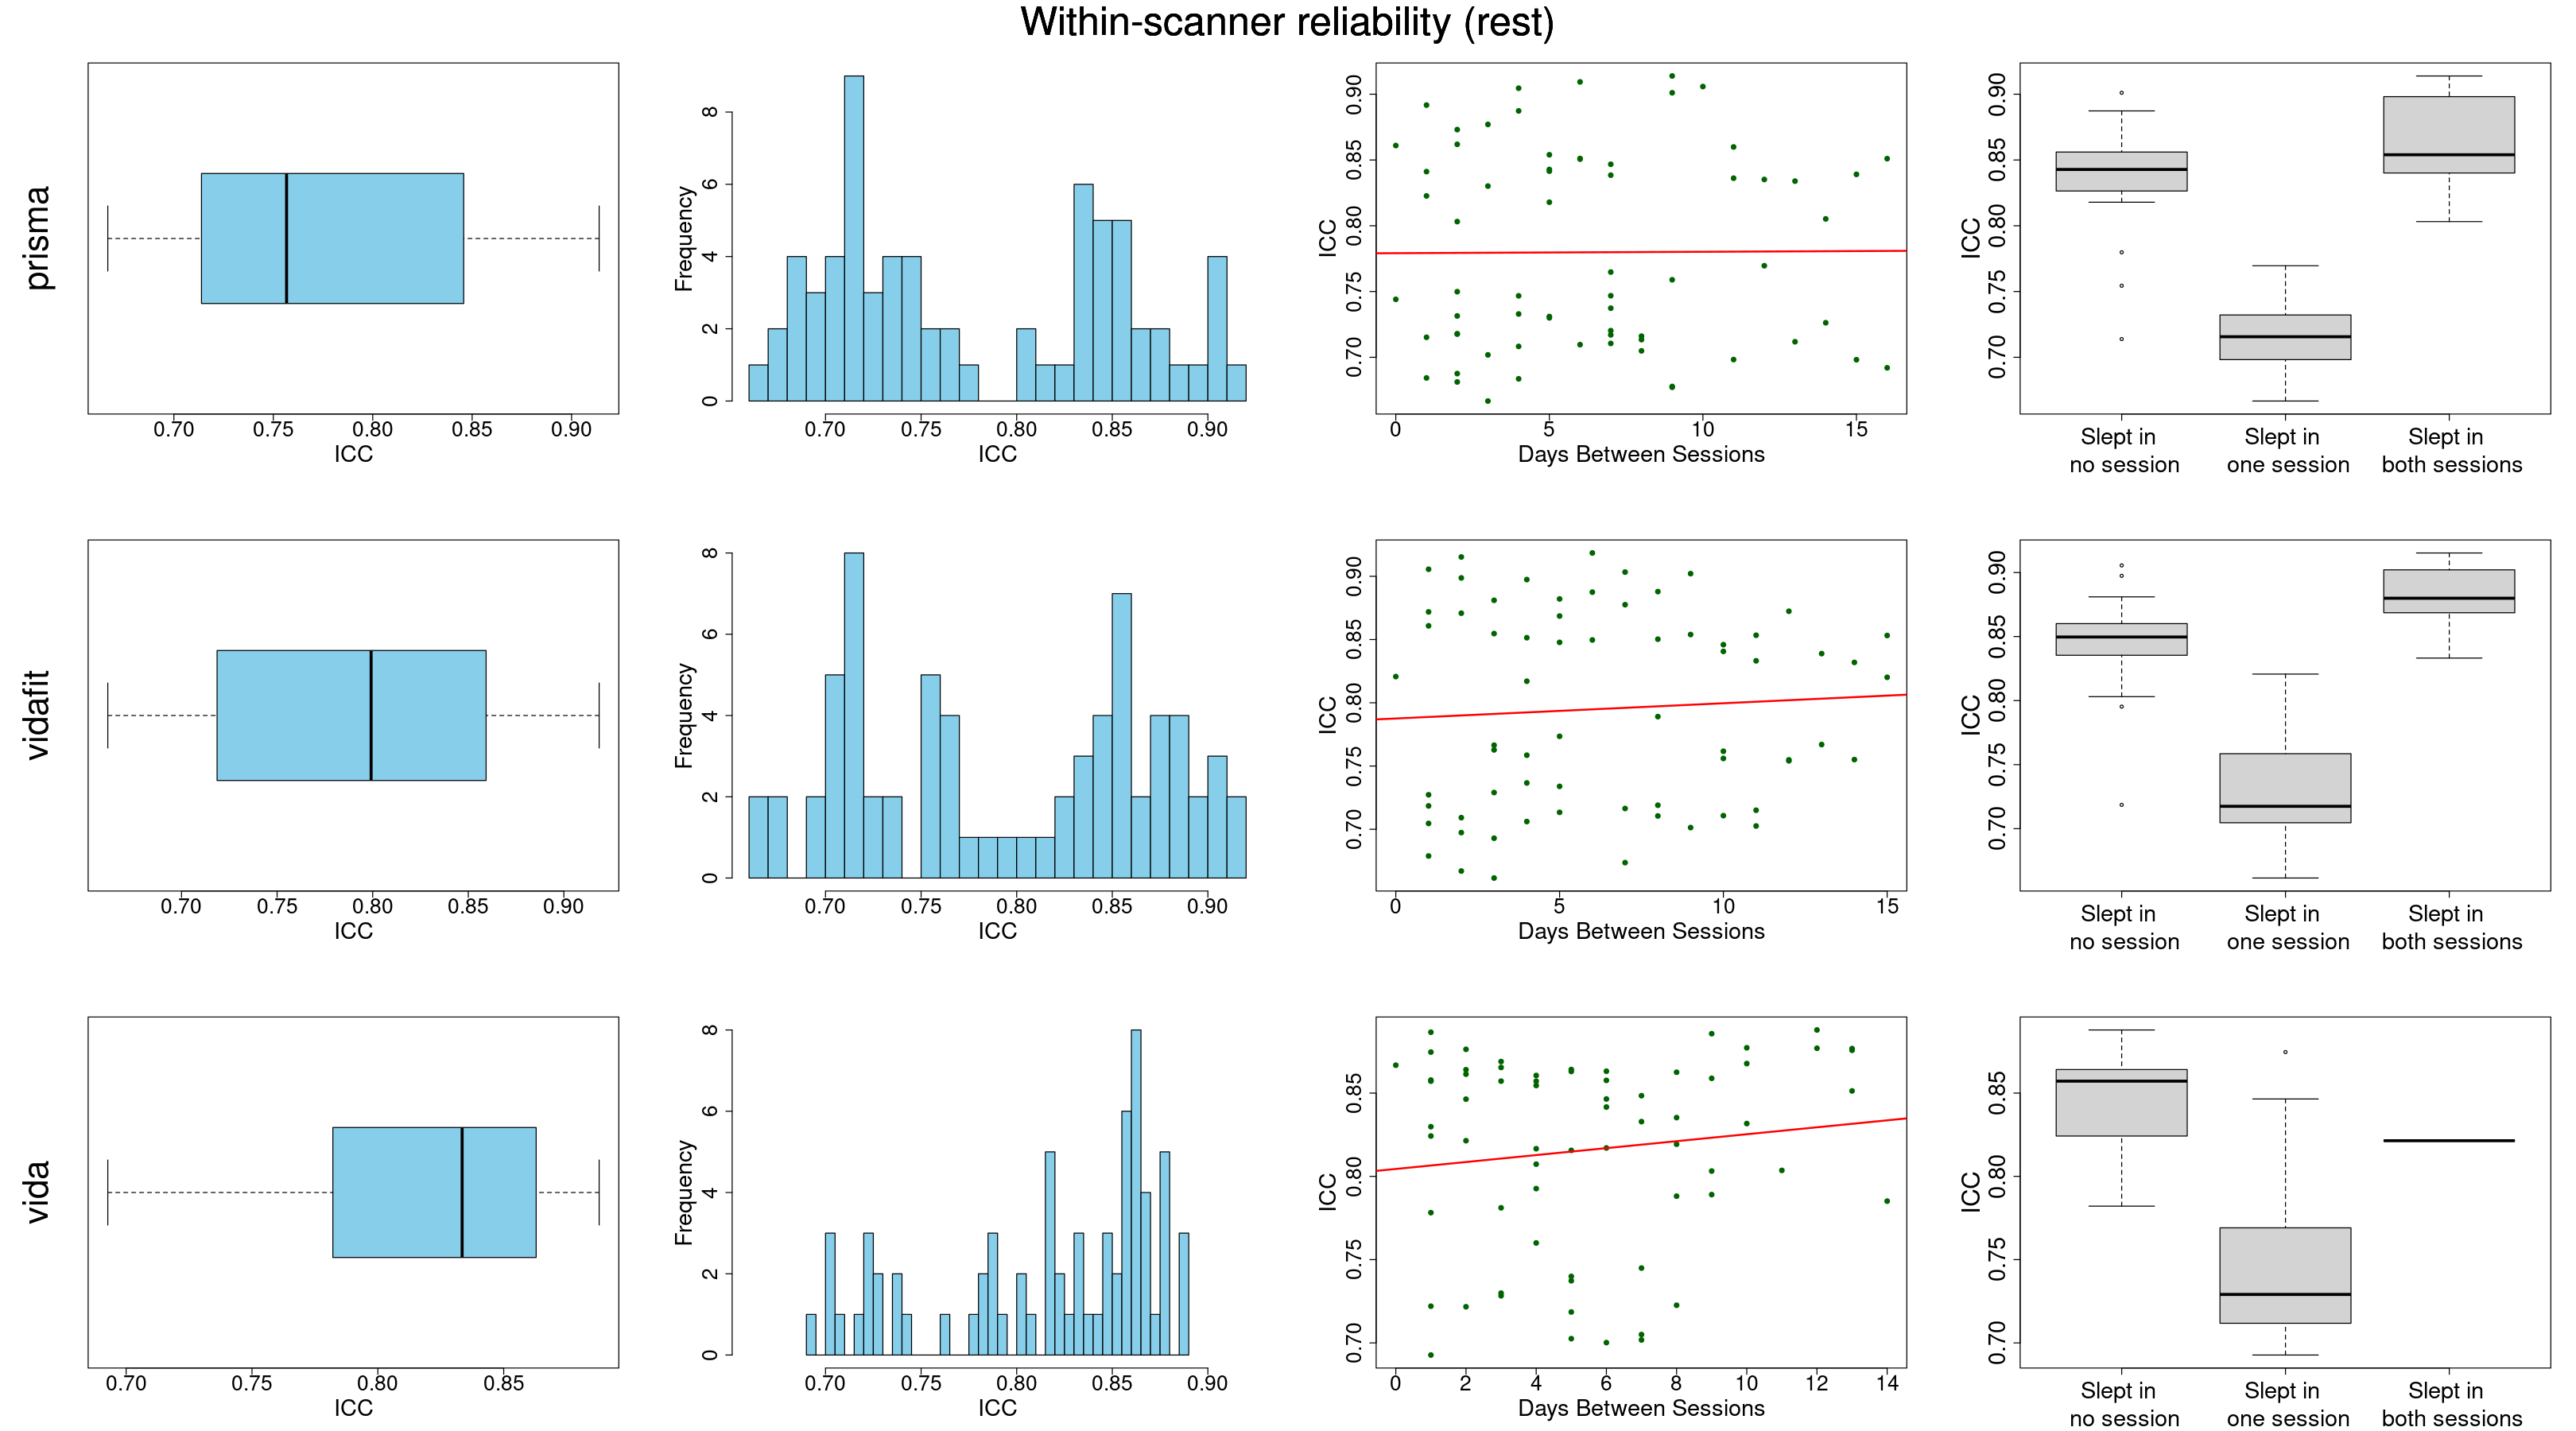

In [217]:
# Set up a 3x3 plotting area for all three scanners
options(repr.plot.width = 27, repr.plot.height = 15)
par(mfrow = c(3, 4), cex.axis = 2, cex.lab = 2.2, cex.main = 2.5, cex.sub = 2, mar = c(5, 7, 5, 2))  # Increase font sizes and margins

# Determine global x-axis limits for ICC
icc_range <- range(icc_intra_rest$ICC, na.rm = TRUE)

icc_intra_rest$slept_factor <- factor(
        icc_intra_rest$slept,
        levels = c(0, 1, 2),
        labels = c("Slept in \n no session", "Slept in \n one session", "Slept in \n both sessions")
    )

for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)

    # Boxplot with fixed xlim
    boxplot(
        icc_intra_rest_scanner$ICC,
        horizontal = TRUE,
        xlab = "ICC",
        col = "skyblue",
        cex.axis = 2,
        cex.lab = 2.2
    )
    mtext(scanner, side = 2, line = 3, cex = 2.2, las = 0)
    # Histogram with fixed xlim
    hist(
        icc_intra_rest_scanner$ICC,
        breaks = 30,
        xlab = "ICC",
        main = '',
        col = "skyblue",
        cex.axis = 2,
        cex.lab = 2.2,
        xlim = icc_range
    )
    # Scatter plot: ICC vs days_diff
    plot(
        icc_intra_rest_scanner$days_diff, icc_intra_rest_scanner$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        pch = 19, col = "darkgreen",
        cex.axis = 2,
        cex.lab = 2.2
    )
    abline(lm(ICC ~ days_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)

    # Sleep influence on ICC
    boxplot(
        ICC ~ slept_factor, data = icc_intra_rest_scanner,
        xlab = "",
        ylab = "ICC",
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5,
        xaxt = "n" # suppress default x-axis
    )
    axis(
        side = 1,
        at = 1:3,
        labels = levels(icc_intra_rest_scanner$slept_factor),
        cex.axis = 2.2,
        padj = 0.8 # move labels lower
    )
    mtext("Within-scanner reliability (rest)", outer = TRUE, line = -3, cex = 2.5)
}
par(mfrow = c(1, 1))  # Reset plotting area


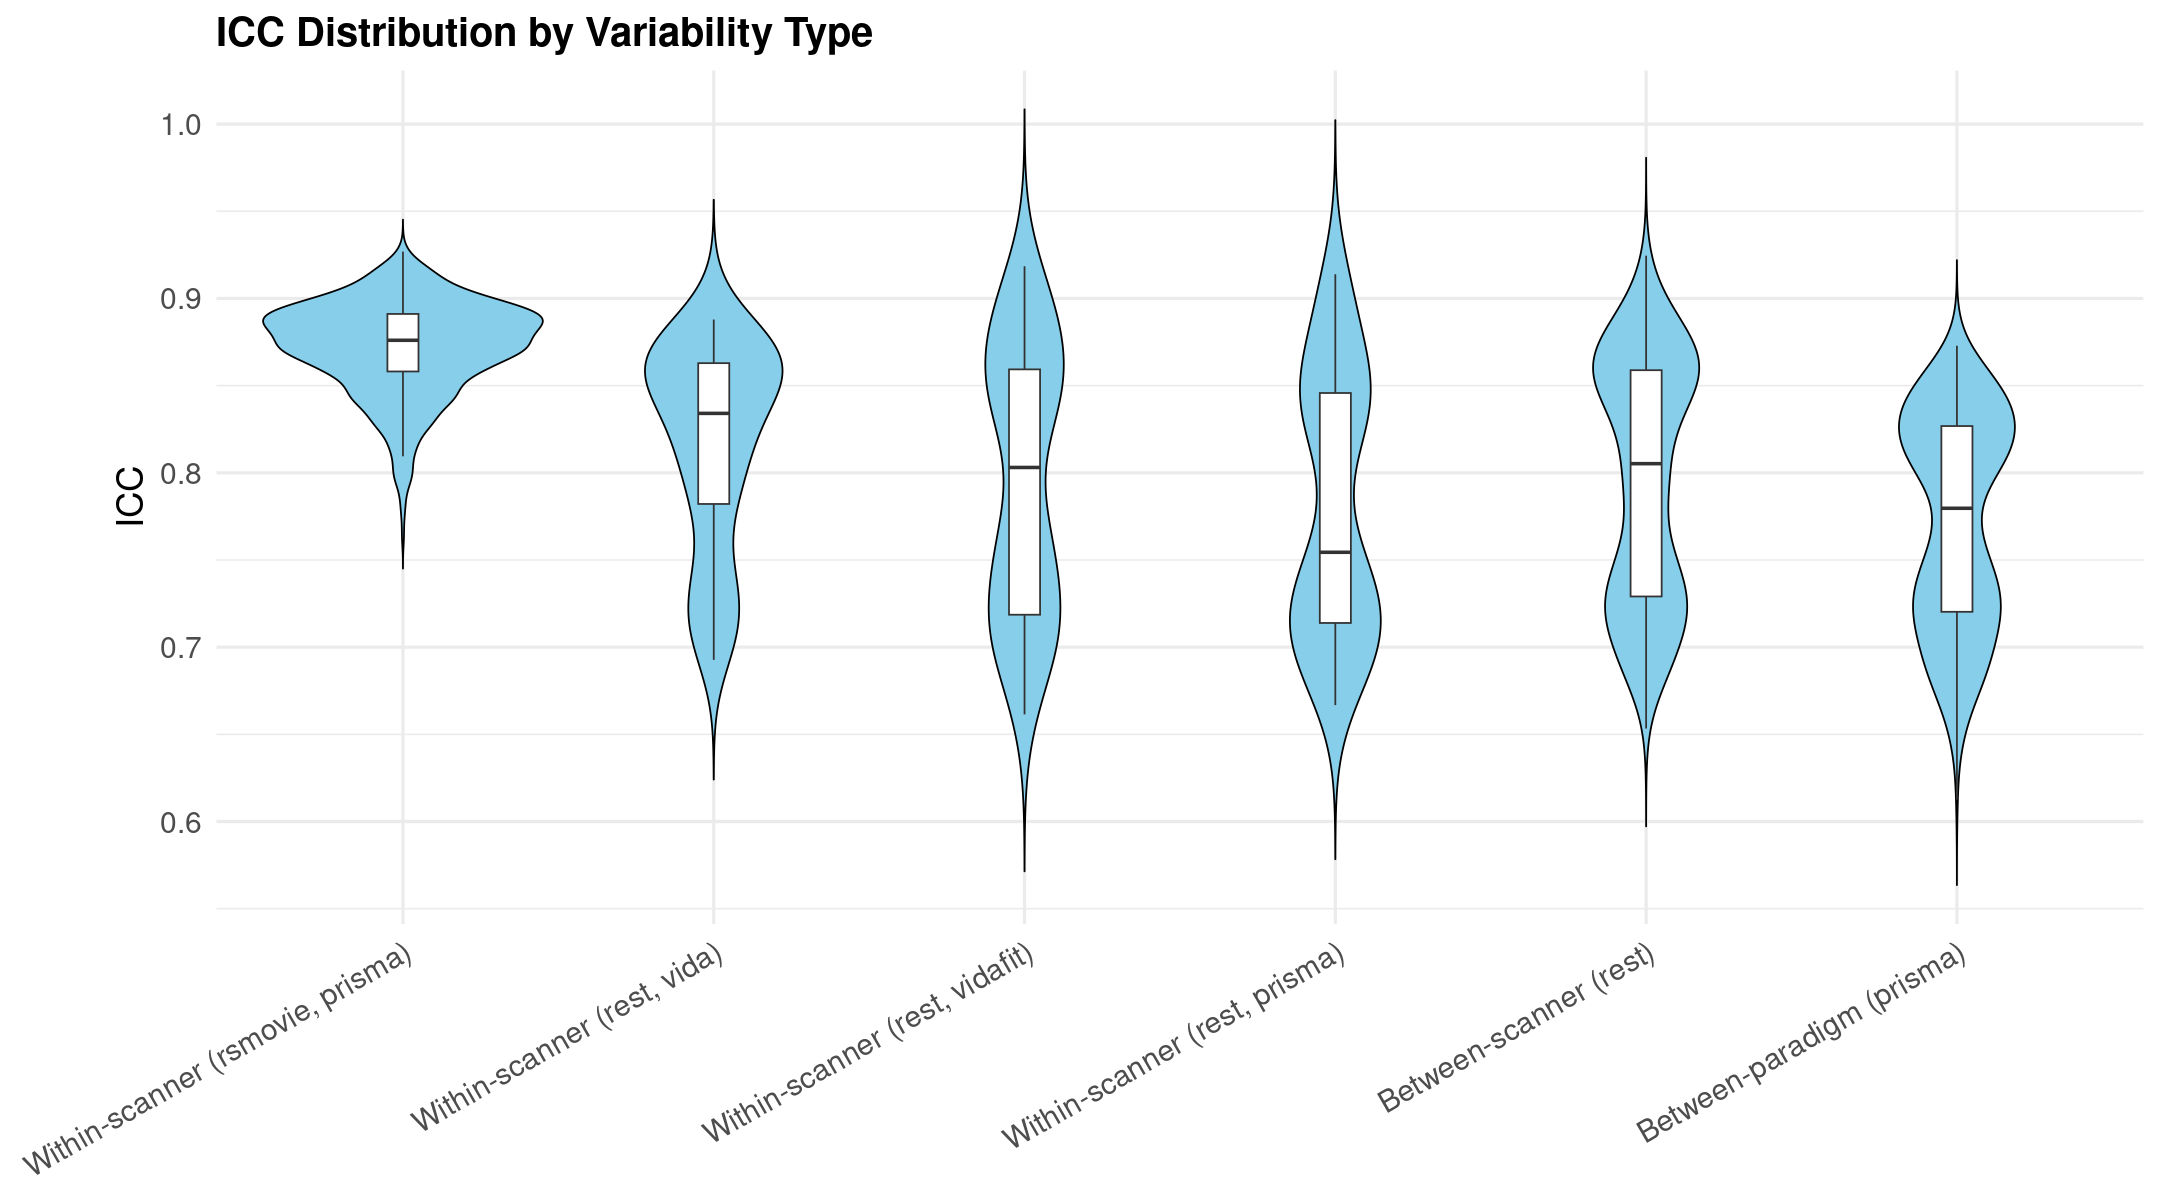

In [229]:
# Reduce the height of the plot by setting the output height (for Jupyter)
options(repr.plot.height = 10)
options(repr.plot.width = 18)

library(ggplot2)
library(dplyr)

# Filter only the bootstrap/permutation ICCs (exclude summary statistics)
df_plot <- icc_results %>%
    filter(is.na(summary_statistic)) %>%
    mutate(
        variability_plotname = case_when(
            variability_type == "within-scanner" & task == "rsmovie" ~ "Within-scanner (rsmovie, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "prisma" ~ "Within-scanner (rest, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vida" ~ "Within-scanner (rest, vida)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vidafit" ~ "Within-scanner (rest, vidafit)",
            variability_type == "between-scanner" ~ "Between-scanner (rest)",
            variability_type == "between-paradigm" ~ "Between-paradigm (prisma)",
            TRUE ~ NA_character_
        )
    )

# Set factor order for plot
df_plot$variability_plotname <- factor(df_plot$variability_plotname, levels = c(
    "Within-scanner (rsmovie, prisma)",
    "Within-scanner (rest, vida)",
    "Within-scanner (rest, vidafit)",
    "Within-scanner (rest, prisma)",    
    "Between-scanner (rest)",
    "Between-paradigm (prisma)"
))

# Plot with increased font size
ggplot(df_plot, aes(x = variability_plotname, y = ICC)) +
    geom_violin(trim = FALSE, color = "black", fill = "skyblue") +
    geom_boxplot(width = 0.1, outlier.shape = NA, fill = "white") +
    theme_minimal(base_size = 20) +
    labs(title = "ICC Distribution by Variability Type", x = NULL, y = "ICC") +
    theme(
        axis.text.x = element_text(angle = 30, hjust = 1, size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.y = element_text(size = 22),
        plot.title = element_text(size = 24, face = "bold"),
        legend.position = "none",
        plot.margin = margin(t = 10, r = 10, b = 10, l = 70)
    )

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'icccomparative'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)
